## 1. Подготовка пайпланов для обработки признаков

In [74]:
import os
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier
from sklearn.metrics import recall_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

from sklearn.model_selection import (cross_val_score, train_test_split, PredefinedSplit,
                                     GridSearchCV, StratifiedKFold, RandomizedSearchCV,
                                     cross_val_predict)


In [3]:
load_path = os.path.join('..', 'data', 'processed', 'eda_telco_customer_churn_train.csv')

df = pd.read_csv(load_path)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4225 entries, 0 to 4224
Data columns (total 24 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                4225 non-null   int64  
 1   Avg Monthly GB Download            4225 non-null   int64  
 2   Avg Monthly Long Distance Charges  4225 non-null   float64
 3   CLTV                               4225 non-null   int64  
 4   Contract                           4225 non-null   object 
 5   Device Protection Plan             4225 non-null   int64  
 6   Gender                             4225 non-null   object 
 7   Internet Service                   4225 non-null   int64  
 8   Multiple Lines                     4225 non-null   int64  
 9   Number of Dependents               4225 non-null   int64  
 10  Offer                              4225 non-null   int64  
 11  Online Backup                      4225 non-null   int64

In [4]:
y_train = df['Churn']
X_train = df.drop(columns=['Churn'])

In [5]:
numeric = ['Age', 'Avg Monthly GB Download', 'Avg Monthly Long Distance Charges', 
           'CLTV', 'Satisfaction Score', 'Tenure in Months', 'Total Long Distance Charges']
print(f'Всего {len(numeric)} числовых признаков')

Всего 7 числовых признаков


In [6]:
categorical = ['Contract', 'Device Protection Plan', 'Gender', 'Internet Service', 'Multiple Lines', 'Offer', 
              'Online Backup', 'Online Security', 'Paperless Billing', 'Partner',
              'Payment Method', 'Premium Tech Support', 'Streaming TV', 'Total Refunds',
              'Number of Dependents', 'Total Extra Data Charges']
print(f'Всего {len(categorical)} категориальных признаков')

Всего 16 категориальных признаков


In [7]:
num_transformer = Pipeline([
    ('scaler', StandardScaler())
])
cat_transformer = Pipeline([
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, numeric),
        ('cat', cat_transformer, categorical)
    ])

Используем StratifiedKFold для кросс-валидации, который позволит сохранять баланс классов в каждом фолде. А валидационный датасет будем исопльзовать для итоговой оценки модели.

In [63]:
load_path = os.path.join('..', 'data', 'processed', 'eda_telco_customer_churn_val.csv')

df_val = pd.read_csv(load_path)
X_val = df_val.drop(columns=['Churn'])
y_val = df_val['Churn']

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## 2. Логистическая регрессия

In [ ]:
lr_model = Pipeline([
    ("preprocessor", preprocessor),
    ("logreg", LogisticRegression(random_state=42))
])

lr_param_grid = {
    'logreg__C': [0.01, 0.1, 1, 10, 100],
    'logreg__l1_ratio': [0, 0.5, 1],
    'logreg__solver': ['saga'],
    'logreg__max_iter': [1000, 2000, 3000]
}

lr_cv = GridSearchCV(
    lr_model,
    param_grid=lr_param_grid,
    cv=cv,
    scoring='recall',
    verbose=1)

lr_cv.fit(X_train, y_train)
print('Baseline (Classification):')
print('Лучшие параметры:', lr_cv.best_params_)
print('Лучшая метрика recall:', lr_cv.best_score_)

Fitting 5 folds for each of 45 candidates, totalling 225 fits
Baseline (Classification):
Лучшие параметры: {'logreg__C': 1, 'logreg__l1_ratio': 1, 'logreg__max_iter': 1000, 'logreg__solver': 'saga'}
Лучшая метрика recall: 0.884031746031746


In [64]:
y_pred = cross_val_predict(lr_cv.best_estimator_, X_val, y_val, cv=cv)
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.98      0.97      1035
           1       0.94      0.87      0.90       374

    accuracy                           0.95      1409
   macro avg       0.95      0.93      0.94      1409
weighted avg       0.95      0.95      0.95      1409



## 3. Random Forest

В качестве baseline-модели возьмём случайный лес. Он не требует масштабирования, хорошо работает с дисбалансом классов и устойчив к выбросам.

In [65]:

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('RF', RandomForestClassifier(random_state=42))
])

rf_param_grid = {
    'RF__n_estimators': [50, 100],  
    'RF__max_depth': [None, 10, 20],
    'RF__min_samples_split': [2, 5],  
    'RF__min_samples_leaf': [1, 4],  
    'RF__max_features': ['sqrt', 'log2'], 
    'RF__class_weight': [None, 'balanced']
}

rf_cv = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    cv=cv,
    scoring='recall',
    n_jobs=-1
)

rf_cv.fit(X_train, y_train)
print('Random Forest:')
print('Лучшие параметры:', rf_cv.best_params_)
print('Лучшая метрика recall:', rf_cv.best_score_)


Random Forest:
Лучшие параметры: {'RF__class_weight': 'balanced', 'RF__max_depth': 10, 'RF__max_features': 'log2', 'RF__min_samples_leaf': 1, 'RF__min_samples_split': 5, 'RF__n_estimators': 50}
Лучшая метрика recall: 0.9179404761904761


In [ ]:
y_pred = cross_val_predict(rf_cv.best_estimator_, X_val, y_val, cv=cv)
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.98      0.97      1035
           1       0.94      0.89      0.91       374

    accuracy                           0.96      1409
   macro avg       0.95      0.93      0.94      1409
weighted avg       0.96      0.96      0.95      1409



In [72]:
best_rf_pipeline = rf_cv.best_estimator_

preprocessor_rf = best_rf_pipeline.named_steps['preprocessor']
best_rf_model = best_rf_pipeline.named_steps['RF']

explainer_rf = shap.TreeExplainer(best_rf_model)
X_val_processed = preprocessor_rf.transform(X_val)
shap_values_rf = explainer_rf.shap_values(X_val_processed)
shap_values_rf_class1 = shap_values_rf[1] if isinstance(shap_values_rf, list) else shap_values_rf


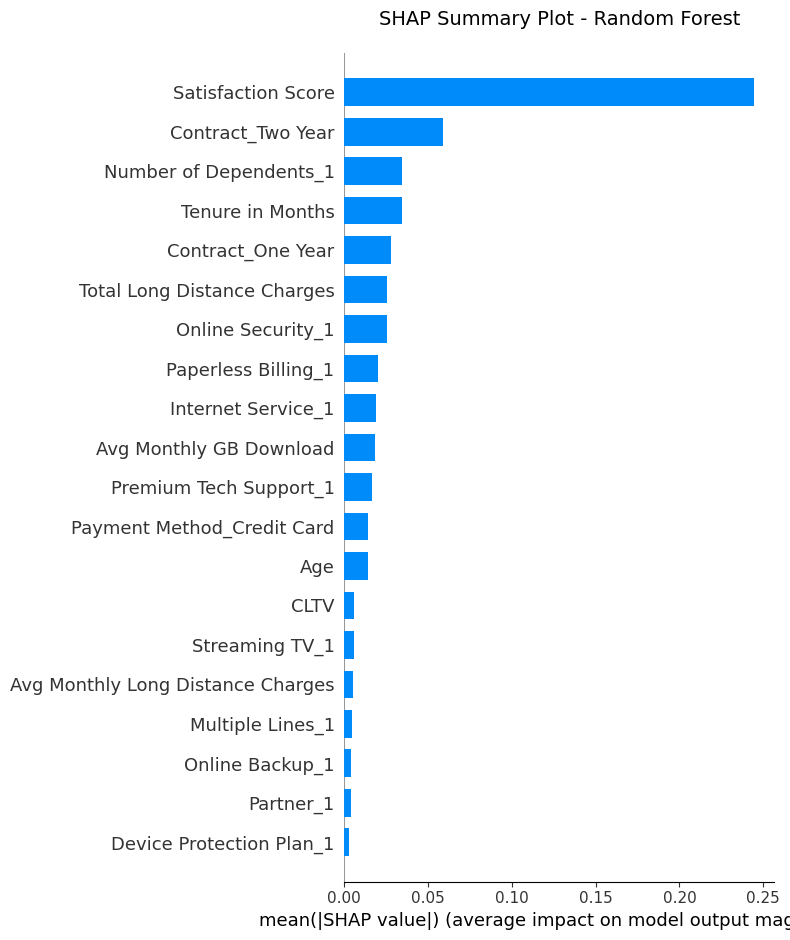

In [93]:
shap.initjs()  # для интерактивных графиков в Jupyter

feature_names = []
for name, transformer, columns in preprocessor.transformers_:
    if name == 'num':
        feature_names.extend(columns)
    elif name == 'cat':
        if hasattr(transformer, 'named_steps') and 'onehot' in transformer.named_steps:
            encoder = transformer.named_steps['onehot']
            feature_names.extend(encoder.get_feature_names_out(columns))
        else:
            feature_names.extend(columns)

shap_values_for_class1 = shap_values_rf_class1[:, :, 1]

plt.figure(figsize=(15, 8))
shap.summary_plot(
    shap_values_for_class1, 
    X_val_processed,
    feature_names=feature_names,
    plot_type="bar",
    show=False,
    max_display=None
)
plt.title('SHAP Summary Plot - Random Forest', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

## 4. Catboost

In [ ]:
catboost_model = CatBoostClassifier(
        cat_features=tuple(categorical),
        random_seed=42,
        verbose=0,
        thread_count=-1,
        auto_class_weights='Balanced',
        early_stopping_rounds=50,
        eval_metric='Recall'
    )

catboost_model.fit(X_train, y_train, 
                      eval_set=(X_val, y_val))
y_pred = catboost_model.predict(X_val)
catboost_recall = recall_score(y_val, y_pred)

print("CatBoost:")
# print(f"Лучшие параметры: {catboost_pipeline.best_params_}")
print(f"Лучшая метрика recall: {catboost_recall:.4f}")

CatBoost:
Лучшая метрика recall: 0.9519


In [57]:
y_pred = cross_val_predict(catboost_model, X_val, y_val, cv=cv)
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.97      0.97      1035
           1       0.92      0.91      0.91       374

    accuracy                           0.96      1409
   macro avg       0.95      0.94      0.94      1409
weighted avg       0.96      0.96      0.96      1409



In [99]:
feature_importance = catboost_model.get_feature_importance()
feature_names = catboost_model.feature_names_
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print("Топ-10 важных признаков (CatBoost):")
print(importance_df.head(10).to_string(index=False))

Топ-10 важных признаков (CatBoost):
                    feature  importance
         Satisfaction Score   85.377431
            Online Security    8.467659
                   Contract    1.496612
       Number of Dependents    1.453084
           Tenure in Months    1.147482
    Avg Monthly GB Download    0.663361
                       CLTV    0.642468
Total Long Distance Charges    0.545729
               Streaming TV    0.206173
                        Age    0.000000


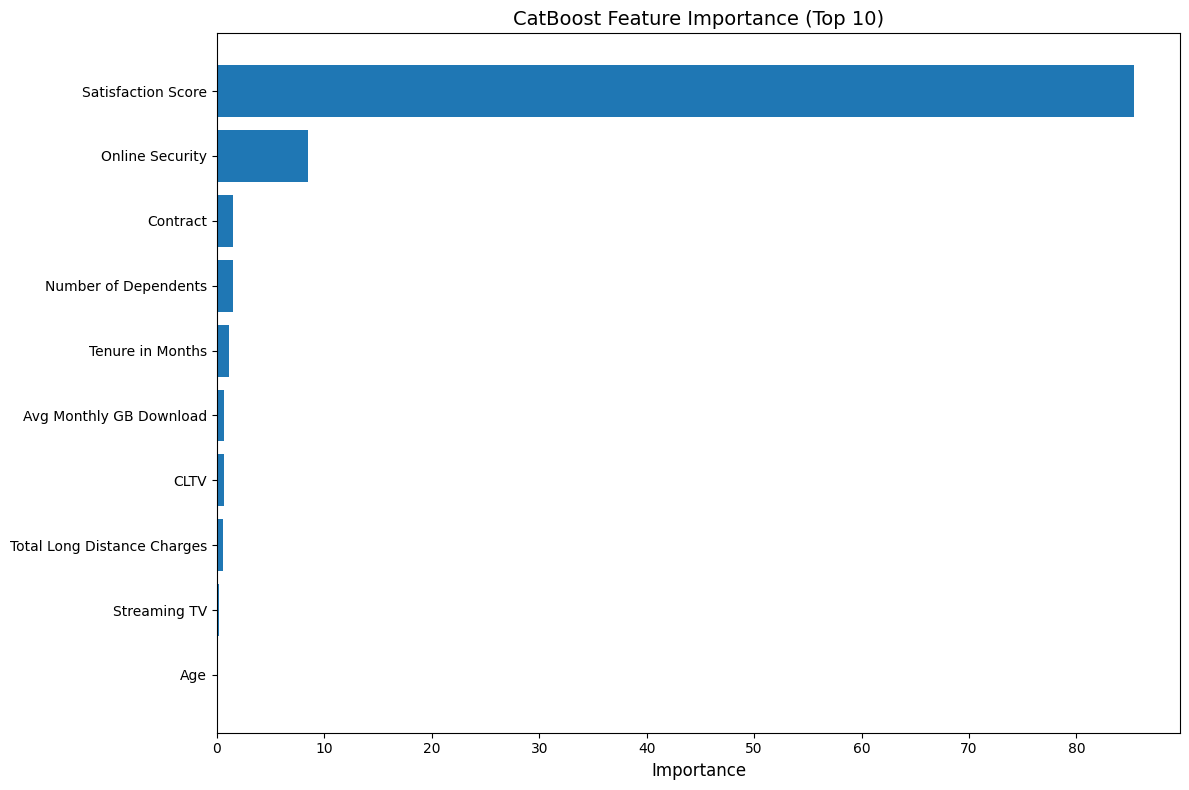

In [100]:
plt.figure(figsize=(12, 8))
plt.barh(importance_df['feature'][:10], importance_df['importance'][:10])
plt.xlabel('Importance', fontsize=12)
plt.title('CatBoost Feature Importance (Top 10)', fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 5. Сравнение моделей

Опишем в таблице метрики моделей на кросс-валидации:

| Модель | Recall | Precision | f1 | accuracy |
|---|-------------|-----------|----|----------|
| Logistic Regression | 0.87 | 0.94| 0.90 | 0.95 |
| Random Forest | 0.89 | 0.94| 0.91 | 0.96 |
| Catboost | 0.91 | 0.92| 0.91 | 0.96 |

Наибольшую метрику Recall показала модель CatBoost: Recall = 0.91. Моедль CatBoost имеет следующие преимущества:

- работает с категориальными признаки "из-под коробки", не требует дополнительных преобразований. В датасете категориальные признаки имеют существенный перевес: 16 против 7 числовых.

- есть встроенный механизм для балансировки классов и оптимизирует метрику Recall напрямую (задаётся в гиперпараметрах)

- использует раннюю остановку, что предотвращает переобучения. Находит оптимальный компромисс bias-variance.

## 6. Проверка на тесте

In [101]:
load_path = os.path.join('..', 'data', 'processed', 'eda_telco_customer_churn_test.csv')

df_test = pd.read_csv(load_path)
X_test = df_test.drop(columns=['Churn'])
y_test = df_test['Churn']

In [103]:
y_pred = catboost_model.predict(X_test)
catboost_recall_test = recall_score(y_test, y_pred)
print('Recall на тесте:', catboost_recall_test)

y_pred = cross_val_predict(catboost_model, X_test, y_test, cv=cv)
print(classification_report(y_test, y_pred))

Recall на тесте: 0.946524064171123
              precision    recall  f1-score   support

           0       0.97      0.96      0.97      1035
           1       0.90      0.92      0.91       374

    accuracy                           0.95      1409
   macro avg       0.93      0.94      0.94      1409
weighted avg       0.95      0.95      0.95      1409



## 7. Итоги

- В качестве предобработки данных был построен pipeline с масштабированием для числовых признаков и One-Hot кодирование для категориальных признаков. 

- В качестве метрики для оценки моделей был выбран Recall, который показывает долю действительно уходящих клиентов среди всех те, кого модель выявила как готовых уйти.

- Были рассмотрены 3 модель: Логистическая регрессия, Случайный лес и CatBoost. На кросс-валидации по метрике Recall лучши себя показала модель CatBoost. 

- На тесте метрика Recall = 0.92 для CatBoost при кросс-валидации, что говорит о том, что модель хорошо различает клиентов, которые готовы у уйти и модель не переобучилась.

- Важность признаков показала, что модель делает прогноз основываясь на на следующих признаках по важности:  Satisfaction Score,  Online Security, Contract, Number of Dependents, Tenure in Months,   Avg Monthly GB Download, CLTV, Total Long Distance Charges, Streaming TV. 